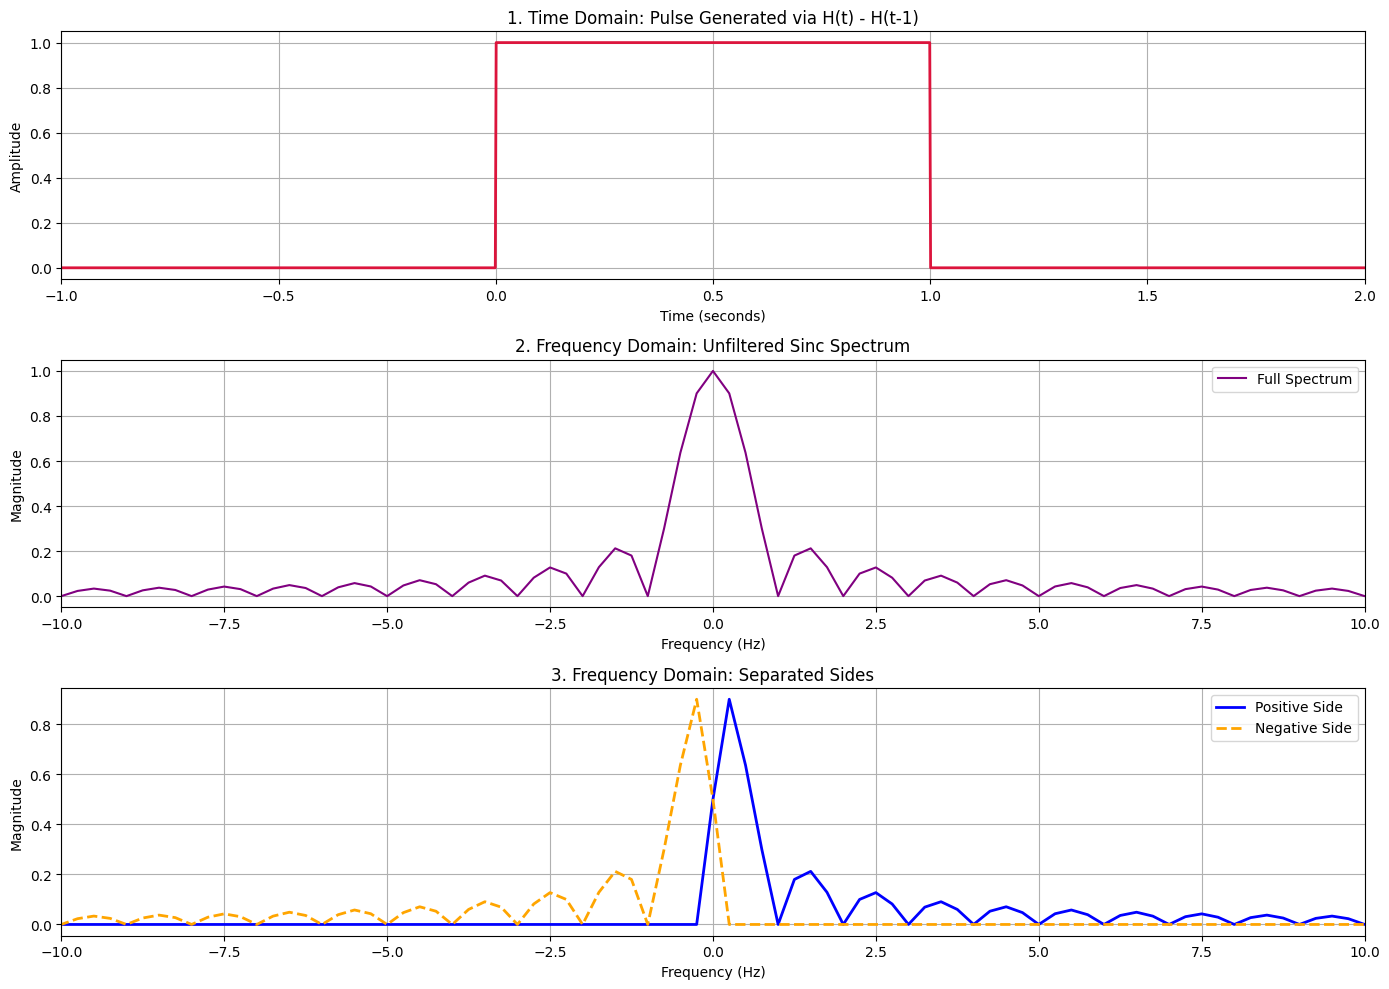

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Time Domain
sampling_rate = 1000
t = np.linspace(-2.0, 2.0, 4000, endpoint=False)

# 2. Define the Rectangular Pulse STRICTLY using Heaviside functions
# H(t) starts at t=0, H(t-1) starts at t=1. Subtracting them leaves a pulse from 0 to 1.
rect_pulse = np.heaviside(t, 0.5) - np.heaviside(t - 1.0, 0.5)

# 3. Compute Raw Fourier Transform
frequencies_raw = np.fft.fftfreq(len(rect_pulse), d=1/sampling_rate)
f_transform_raw = np.fft.fft(rect_pulse)

# 4. Center the spectrum around 0 Hz
frequencies = np.fft.fftshift(frequencies_raw)
f_transform = np.fft.fftshift(f_transform_raw)

# 5. Create and Apply Frequency-Domain Heaviside Filters
heaviside_positive = np.heaviside(frequencies, 0.5)
heaviside_negative = np.heaviside(-frequencies, 0.5)

positive_side = f_transform * heaviside_positive
negative_side = f_transform * heaviside_negative

# 6. Normalize magnitudes for plotting
mag_full = np.abs(f_transform)/sampling_rate
mag_positive = np.abs(positive_side)/ sampling_rate
mag_negative = np.abs(negative_side)/ sampling_rate

# 7. Visualization
plt.figure(figsize=(14, 10))

# Plot 1: Time Domain Signal
plt.subplot(3, 1, 1)
plt.plot(t, rect_pulse, color='crimson', lw=2)
plt.title("1. Time Domain: Pulse Generated via H(t) - H(t-1)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.xlim(-1, 2)
plt.grid(True)

# Plot 2: Full Sinc Spectrum
plt.subplot(3, 1, 2)
plt.plot(frequencies, mag_full, color='purple', label='Full Spectrum')
plt.title("2. Frequency Domain: Unfiltered Sinc Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(-10, 10)
plt.grid(True)
plt.legend()

# Plot 3: Heaviside Filtered Sides
plt.subplot(3, 1, 3)
plt.plot(frequencies, mag_positive, color='blue', lw=2, label='Positive Side')
plt.plot(frequencies, mag_negative, color='orange', lw=2, linestyle='--', label='Negative Side')
plt.title("3. Frequency Domain: Separated Sides")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(-10, 10)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


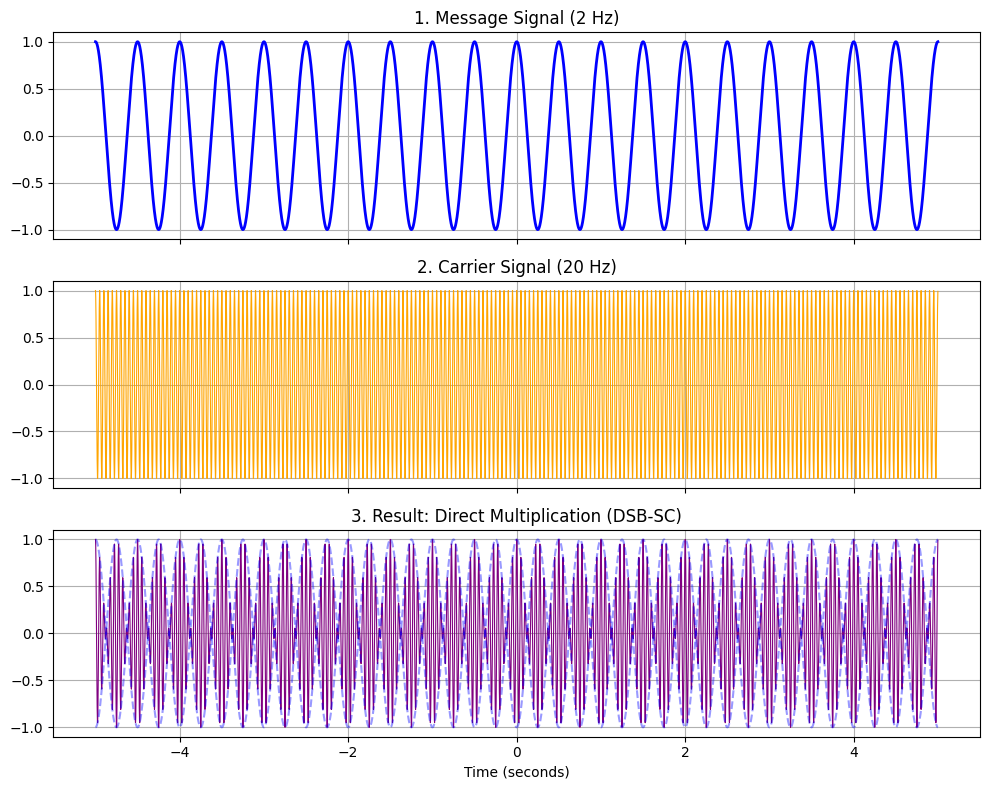

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rate = 1000
duration = 10
sampling = int(rate * duration)

# 10-second window from -5 to 5
t = np.linspace(-5, 5, sampling, endpoint=False)

# Lowered frequencies to prevent aliasing over a wide time window
fa = 2   # Message frequency (2 Hz)
fb = 20  # Carrier frequency (20 Hz)

a = np.cos(2*np.pi*fa*t)
b = np.cos(2*np.pi*fb*t)
c = a*b

# Visualize
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Message
axs[0].plot(t, a, color='blue', linewidth=2)
axs[0].set_title("1. Message Signal (2 Hz)")
axs[0].grid(True)

# Carrier
axs[1].plot(t, b, color='orange', linewidth=0.8)
axs[1].set_title("2. Carrier Signal (20 Hz)")
axs[1].grid(True)

#MODULATED
axs[2].plot(t, c, color='purple', linewidth=0.8)

#COMPARISON(USING POSITIVE AND NEGATIVE OF MESSAGE SIGNAL TO ENVELOP N SHII)
axs[2].plot(t, a, color='blue', linestyle='--', alpha=0.4)
axs[2].plot(t, -a, color='blue', linestyle='--', alpha=0.4)
axs[2].set_title("3. Result: Direct Multiplication (DSB-SC)")
axs[2].grid(True)
axs[2].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()


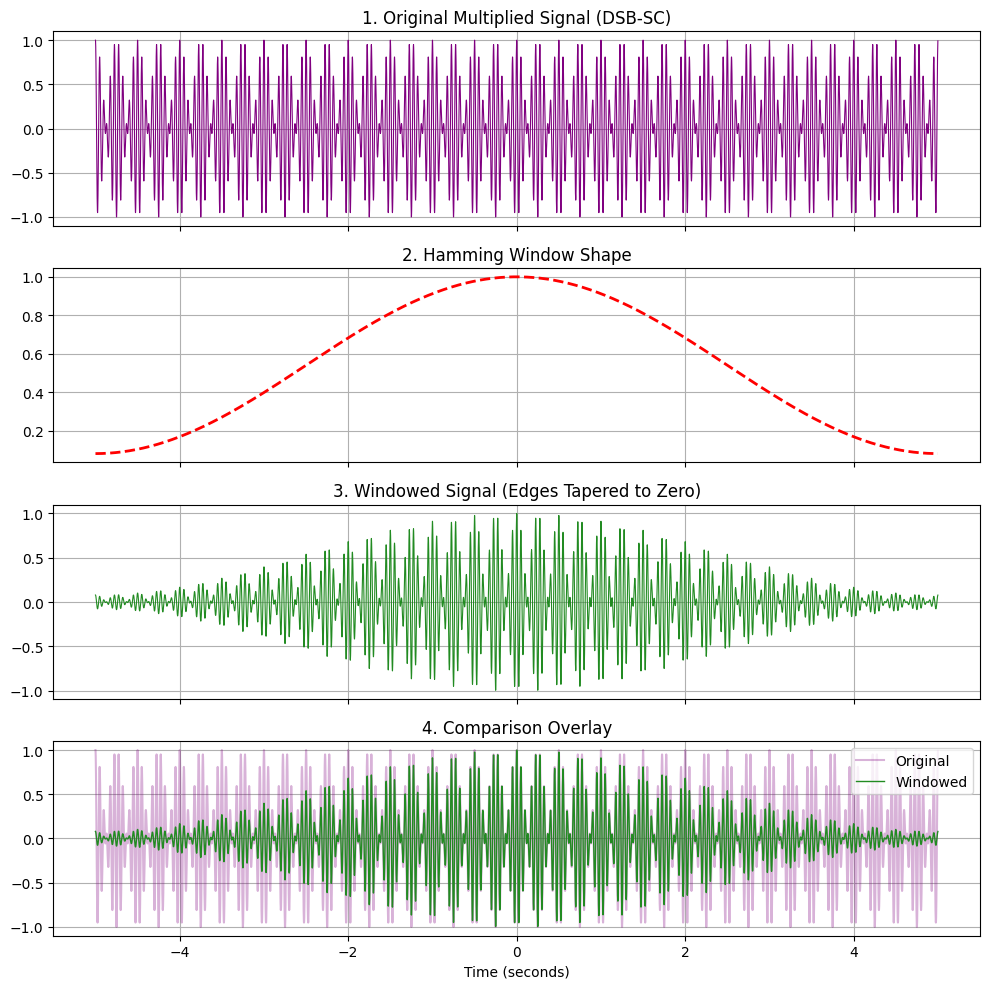

In [ ]:
# HAMMING WINDOW

import numpy as np
import matplotlib.pyplot as plt

rate = 1000
duration = 10
sampling = int(rate * duration)

t = np.linspace(-5, 5, sampling, endpoint=False)
fa = 2
fb = 20

a = np.cos(2*np.pi*fa*t)
b = np.cos(2*np.pi*fb*t)
c = a * b


window = np.hamming(sampling)


windowed_signal = c * window


fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)


axs[0].plot(t, c, color='purple', linewidth=0.8)
axs[0].set_title("1. Original Multiplied Signal (DSB-SC)")
axs[0].grid(True)


axs[1].plot(t, window, color='red', linewidth=2, linestyle='--')
axs[1].set_title("2. Hamming Window Shape")
axs[1].grid(True)

axs[2].plot(t, windowed_signal, color='forestgreen', linewidth=0.8)
axs[2].set_title("3. Windowed Signal (Edges Tapered to Zero)")
axs[2].grid(True)


axs[3].plot(t, c, color='purple', alpha=0.3, label='Original')
axs[3].plot(t, windowed_signal, color='forestgreen', linewidth=1, label='Windowed')
axs[3].set_title("4. Comparison Overlay")
axs[3].grid(True)
axs[3].set_xlabel("Time (seconds)")
axs[3].legend(loc="upper right")

plt.tight_layout()
plt.show()


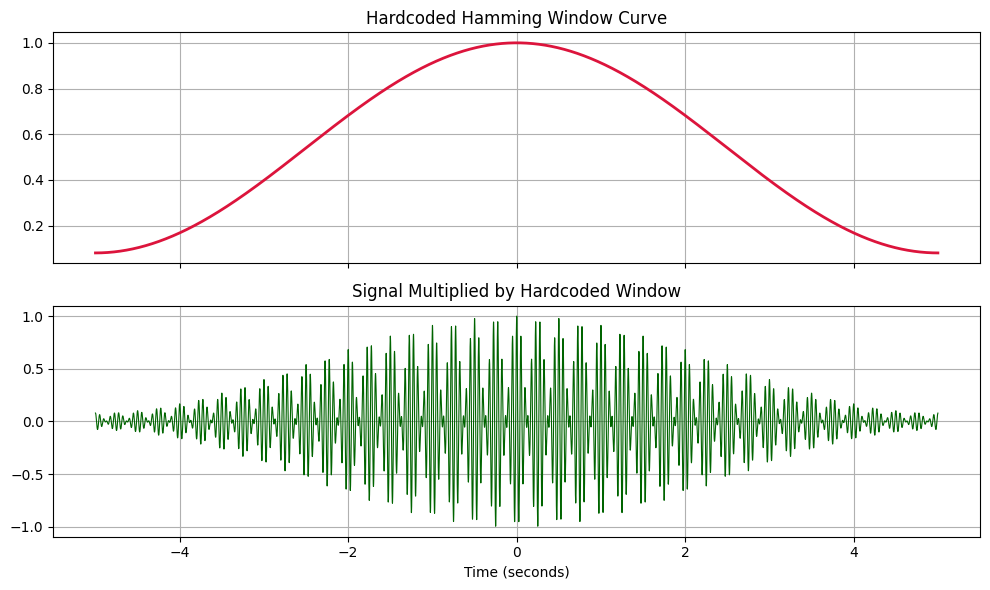

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rate = 1000
duration = 10
sampling = int(rate * duration)

t = np.linspace(-5, 5, sampling, endpoint=False)
fa = 2
fb = 20

a = np.cos(2*np.pi*fa*t)
b = np.cos(2*np.pi*fb*t)
c = a * b

# --- Hardcode the Hamming Window ---
# 1. Create an index array 'n' from 0 to N-1
n = np.arange(sampling)

# 2. Apply the exact formula
custom_window = 0.54 - 0.46 * np.cos((2 * np.pi * n) / (sampling - 1))

# --- Apply it to your signal ---
windowed_signal = c * custom_window

# Visualize to verify it matches perfectly
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# The Custom Window
axs[0].plot(t, custom_window, color='crimson', linewidth=2)
axs[0].set_title("Hardcoded Hamming Window Curve")
axs[0].grid(True)

# The Resulting Signal
axs[1].plot(t, windowed_signal, color='darkgreen', linewidth=0.8)
axs[1].set_title("Signal Multiplied by Hardcoded Window")
axs[1].grid(True)
axs[1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()


#WHITE GAUSSIAN NOISE SEQUENCE

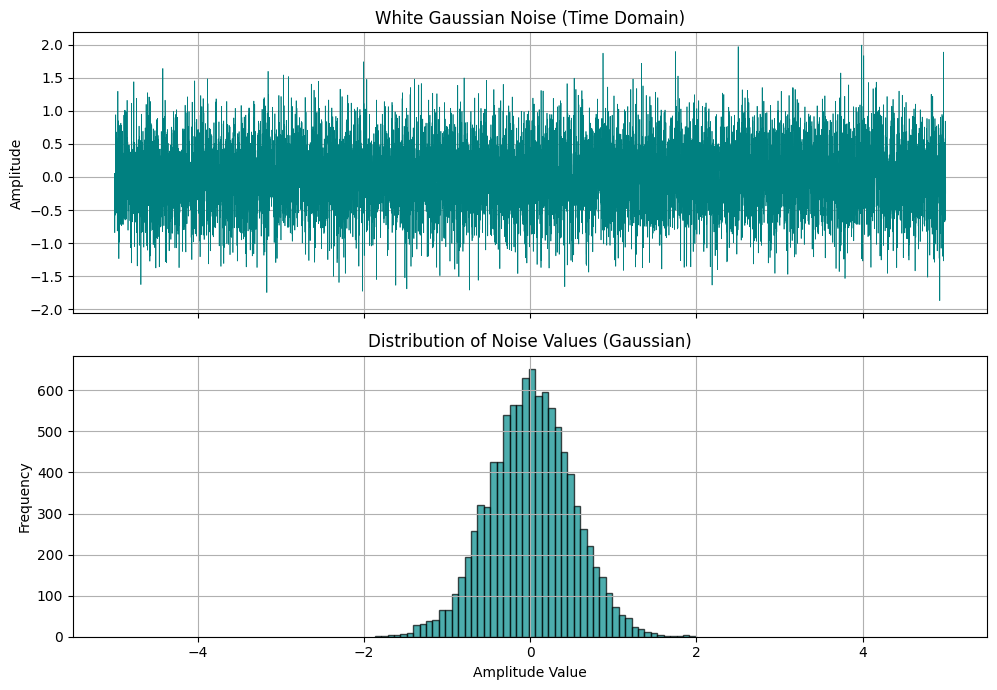

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define sampling parameters
rate = 1000
duration = 10
sampling = int(rate * duration)
t = np.linspace(-5, 5, sampling, endpoint=False)

# 2. Generate White Gaussian Noise
# loc = mean (average value of the noise, usually 0)
# scale = standard deviation (controls the "loudness" or power of the noise)
mean = 0.0
std_dev = 0.5

noise = np.random.normal(loc=mean, scale=std_dev, size=sampling)

# 3. Visualize the noise
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Time Domain Plot
axs[0].plot(t, noise, color='teal', linewidth=0.5)
axs[0].set_title("White Gaussian Noise (Time Domain)")
axs[0].grid(True)
axs[0].set_ylabel("Amplitude")

# Histogram Plot (To verify the Gaussian Bell Curve)
axs[1].hist(noise, bins=50, color='darkcyan', edgecolor='black', alpha=0.7)
axs[1].set_title("Distribution of Noise Values (Gaussian)")
axs[1].grid(True)
axs[1].set_xlabel("Amplitude Value")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
